<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Acesso aos dados do ERA5 através do Earth Data Catalogue

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dr. Pedro Leite da Silva Dias
* Prof. Dr. Ricardo Hallak


<p align="left"> <font size=5 color='#002883'> Estudante:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

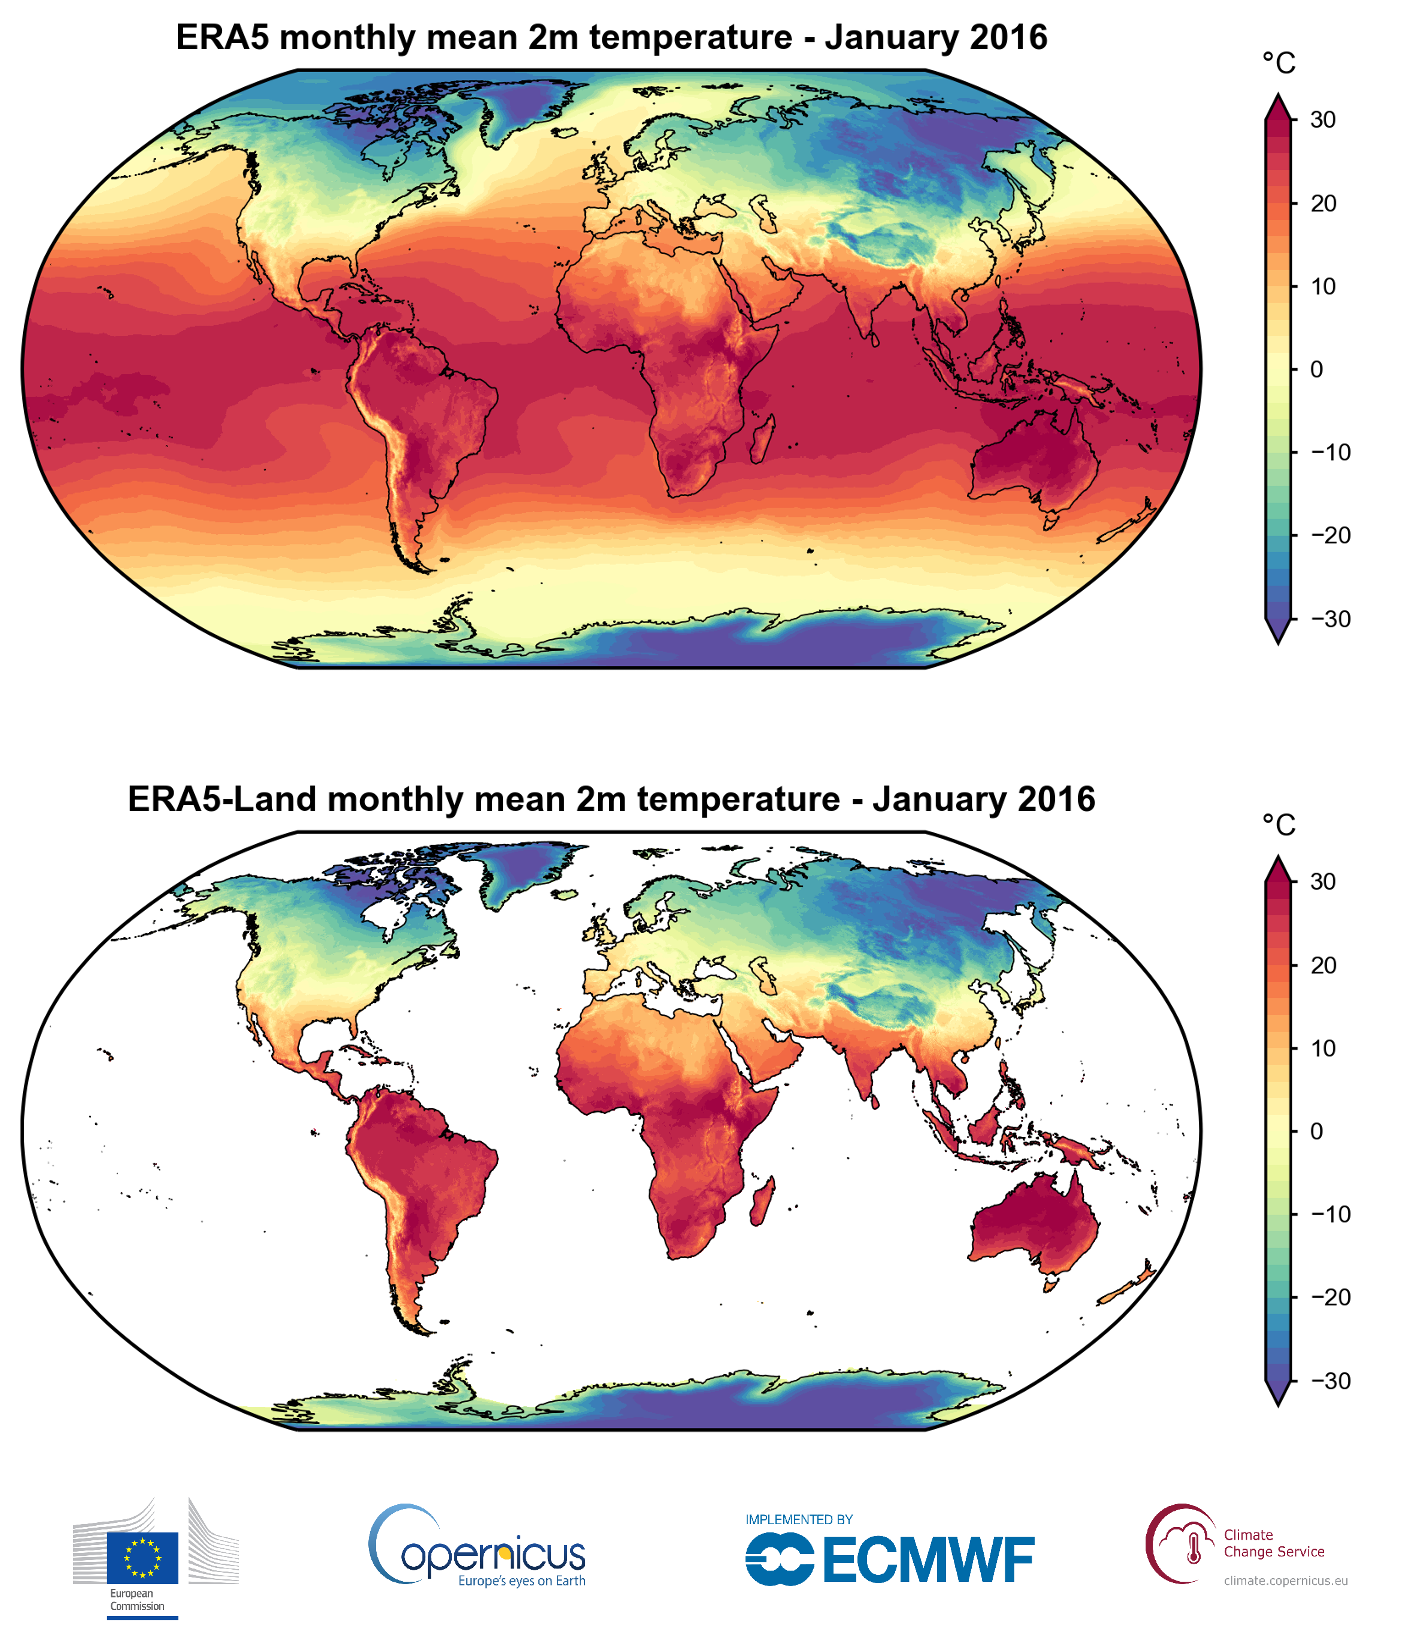

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as duas células de abaixo: <font>

In [ ]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture
!pip install xarray netCDF4 scipy scikit-learn dask pydap bottleneck h5netcdf
!pip install store zarr
!pip install uv
!pip install cartopy
!pip install cmocean
!pip install metpy

<font size=4 color='#002883'> **2. Importar livrarias e montar o drive** <font>

In [ ]:
# @title #### <font color='#002883'> Importar livrarias <font>
%%capture
# Livrarias para ler e processar dados
import xarray as xr
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import metpy.calc as mpcalc
from metpy.units import units

# Livrarias para gerar gráficos
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean as cmo
import os

# Importar o drive
from google.colab import drive
drive.mount('/content/drive')

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **3. Acessar aos dados do [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue)** <font>

- <font size=4 color='#002883'>Earth Data catalogue link: [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue) <font>

<font size=4 color= '#002883'>**Acessar ao Site e criar uma conta, no qual vocês poderão criar seus própios tokens, necessários para fazer usso dos diferentes conjuntos de dados disponíveis <font>**.

<font size=4 color= 'red'>**Observação: O token do exemplo é temporário, por tal motivo é possível que se você não mudar com seu próprio token a seguinte célula não consiga ser executada. <font>**.

In [ ]:
# @title #### <font color='#002883'> Acessar através do access token <font>
%%capture
token = "edh_pat_d2c59b08304ab1489023f5c02db65f5bf6fc852132871ec4f00bd467d161b66655d85b2a7415725b7c2b6ca8bfed27c0"
edh_pat = os.getenv("EDH_PAT", token)

assert edh_pat.startswith("edh_pat_"), (
    f"Your personal access token is a long string starting with 'edh_pat_', not {edh_pat!r}"
)

<font size=4 color='#002883'> **4. Ler o dataset horário do ERA5
utilizando o token** <font>

<font size=4 color='#002883'> **Se acessa ao conjunto de dados do ERA5 Pressure Levels, devido a que as variáveis de interesse para executar o software ATMOSBUD para o balanço de energia, vorticidade e umidade do ciclone/furacão são: vento zonal (u), vento meridional (v), vento vertical (omega, w), temperatura (t), umidade específica (q) e altura geopotencial (z).** <font>

In [ ]:
# @title #### <font color='#002883'> Ler dataset utiizando o token  <font>
#%%capture

# Link de acesso aos dados horários por níveis de pressão de todo o histórico do ERA5
link_era5_pressure_levels = "data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr"
# Ler dataset
era5_pressure_levels_hourly = xr.open_dataset(
    f"https://edh:{edh_pat}@{link_era5_pressure_levels}",
    chunks={},
    engine="zarr",
)

# Display dos dados
era5_pressure_levels_hourly

<xarray.Dataset> Size: 956TB
Dimensions:        (valid_time: 757512, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-05-31T...
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **5. Selecionar a área de estudo, em função do ciclone/furacão de interesse. Neste caso, como exemplo foi eleito o furacão Catarina. Converter as longitudes do formato de 0° a 360° para o formato de -180° a +180° (Porém, se for necessário pode manter o formato de 0° - 360°). Selecionar o período de estudo (e.g., O furacão Catarina aconteceu entre 20 de março de 2004 até o dia 28 de março de 2004). Finalmente, selecionar os níveis de pressão** <font>

In [ ]:
# @title #### <font color='#002883'> Selecionar a área, tranfomar o formato das longitudes e escolher o período  <font>
#%%capture

# Selecionar área e período
# Data inicial
start_time = '2004-03-20'
# Data final
end_time = '2004-03-28'

# Selecionar as latitudes e longitudes minima e máximo
lon_min = -70
lon_max = -20
lat_min = -50
lat_max = -15

# Selecionar período
ds = era5_pressure_levels_hourly.sel(
    latitude=slice(lat_max, lat_min),
    valid_time=slice(start_time,end_time)
)

# Dar atributos à coordenada de tempo
ds["valid_time"].attrs.update({
    "long_name": "time",
    "standard_name": "time",
})

# Selecionar os níveis de pressão, e.g., 1000 até 100 hPa
ds = ds.sel(isobaricInhPa=slice(1000,100))

# Renomear a coordenada vertical
ds = ds.rename({"isobaricInhPa":"pressure_level"})

# Dar atributos à coordenada vertical, e.g., a unidade hPa
ds["pressure_level"].attrs.update({
    "long_name": "pressure",
    "units": "hPa",
    "positive": "down",
    "stored_direction": "decreasing",
    "standard_name": "air_pressure",
})

# Variáveis selecionadas para o ATMOSBUD
vars_keep = ["u","v","w","q","t","z"]
ds = ds[vars_keep]

# Transformar o formato das longitudes
ds['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
ds = ds.sortby(ds.longitude)

# Selecionar área e período
ds = ds.sel(
    longitude=slice(lon_min, lon_max)
)

# Selecionar os pasos de tempo, e.g., time_step = 3 horas ou 6 horas
time_step = 6 # horas: Pode trocar para 3
hours_keep = list(range(0,24,time_step))
ds = ds.sel(
    valid_time = ds.valid_time.dt.hour.isin(hours_keep)
)

# Visualizar o novo dataset
ds

<xarray.Dataset> Size: 294MB
Dimensions:         (valid_time: 36, pressure_level: 12, latitude: 141,
                     longitude: 201)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 288B 2004-03-20 ... 2004-03-2...
  * pressure_level  (pressure_level) int32 48B 1000 925 850 700 ... 200 150 100
  * latitude        (latitude) float64 1kB -15.0 -15.25 -15.5 ... -49.75 -50.0
  * longitude       (longitude) float64 2kB -70.0 -69.75 -69.5 ... -20.25 -20.0
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 49MB dask.array<chunksize=(36, 1, 92, 40), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **6. Salvar o dataset do ERA5 como um NetCDF file. É necessário escrever o path (caminho) do espaço em nosso drive onde ele será direcionado com o objetivo de ser utilizado para outros processos (e.g., como input do ATMOSBUD). Salvar o NetCDF precisa de um tempo de vários minutos em função do período escolhido, os passos de tempo (a cada 3, 6 ou 12 horas) e o tamanho da área selecionada. No possível fazer isso com anticipação.** <font>

In [ ]:
# @title #### <font color='#002883'> Salvar NetCDF file no meu drive  <font>
#%%capture

# Editar o path do seu respectivo espaço de trabalho do seu drive
path_out = "/content/drive/MyDrive/equipe4_catarina.nc"
# Procedimento para obter um file NetCDF de menor tamanho
comp = dict(zlib=True, complevel=5)
encoding = {var: comp for var in ds.data_vars}

# Salvar NetCDF file
ds.to_netcdf(path_out, encoding=encoding, compute=True)

<font size=4 color='#002883'> **7. Abrir o NetCDF file que foi salvado em nosso espaço de trabalho do nosso drive** <font>

In [ ]:
# @title #### <font color='#002883'> Ler o NetCDF file que foi salvado no nosso drive <font>
#%%capture
file_nc = xr.open_dataset("/content/drive/MyDrive/equipe4_catarina.nc")
file_nc

<xarray.Dataset> Size: 294MB
Dimensions:         (valid_time: 36, pressure_level: 12, latitude: 141,
                     longitude: 201)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 288B 2004-03-20 ... 2004-03-2...
  * pressure_level  (pressure_level) int32 48B 1000 925 850 700 ... 200 150 100
  * latitude        (latitude) float64 1kB -15.0 -15.25 -15.5 ... -49.75 -50.0
  * longitude       (longitude) float64 2kB -70.0 -69.75 -69.5 ... -20.25 -20.0
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
    w               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
    z               (valid_time, pressure_level, latitude, longitude) float32 49MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **8. Fazer uma animação de teste com o NetCDF file que foi salvado** <font>

In [ ]:
# @title #### <font color='#002883'> Criar uma animação com o NetCDF file que foi salvado <font>
#%%capture
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================================================
# Preparar variável
# ==========================================================
g = 9.80665

z850 = file_nc["z"].sel(pressure_level=850) / g
z850.name = "z850"
z850.attrs["units"] = "m"

# Para a animação ficar leve, usar a cada 6 horas
time_step = 1
z850_anim = z850.isel(valid_time=slice(None, None, time_step))

lat_name = "latitude"
lon_name = "longitude"
time_name = "valid_time"

lat = z850_anim[lat_name]
lon = z850_anim[lon_name]

lon_min = float(lon.min())
lon_max = float(lon.max())
lat_min = float(lat.min())
lat_max = float(lat.max())

vmin = float(z850_anim.quantile(0.02).compute())
vmax = float(z850_anim.quantile(0.98).compute())
levels = np.linspace(vmin, vmax, 21)

# ==========================================================
# Criar figura
# ==========================================================
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

def draw_frame(i):
    ax.clear()

    da = z850_anim.isel(valid_time=i)
    time_str = np.datetime_as_string(da[time_name].values, unit="h")

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    cf = ax.contourf(
        lon,
        lat,
        da,
        levels=levels,
        cmap="viridis",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    cs = ax.contour(
        lon,
        lat,
        da,
        levels=levels[::2],
        colors="k",
        linewidths=0.5,
        transform=ccrs.PlateCarree()
    )

    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.add_feature(cfeature.RIVERS, linewidth=0.4, alpha=0.7)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"850-hPa Geopotential Height\n{time_str}", fontsize=12)

    return cf

# Primeiro frame para criar a colorbar
cf0 = draw_frame(0)

cbar = plt.colorbar(
    cf0,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.85
)
cbar.set_label("850-hPa geopotential height [m]")

# Criar animação
ani = FuncAnimation(
    fig,
    draw_frame,
    frames=len(z850_anim[time_name]),
    interval=300,
    repeat=True
)

plt.close(fig)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.